# Chronos-2 — CATSA Train → EmpaticaE4 Test (ACC only)

**Model**: Amazon Chronos-2 (Chronos-T5-small, fine-tuning)
- 사전학습된 시계열 파운데이션 모델 (T5 기반, d_model=512)
- Channel-independent: X/Y/Z 3축 각각 독립 인코딩 후 concatenate
- 1920→480 서브샘플링(÷4)으로 512 토큰 컨텍스트 제한에 맞춤
- 상위 Transformer 레이어 + 분류 헤드를 fine-tuning
- 참고: *Unified Training of Universal Time Series Forecasting Transformers* (Woo et al., 2024)

**학습**: CATSA 전체 피험자 (ACC 3축, 32Hz)  
**평가**: EmpaticaE4Stress (subject_01 ~ subject_06)

---
**설치 필요**: `pip install chronos-forecasting`

In [1]:
import json, math, warnings
import numpy as np
import pandas as pd
from copy import deepcopy
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

TASKS        = ["Baseline", "Logic", "Nback", "Stroop", "Sudoku"]
STRESS_TASKS = {"Logic", "Nback", "Stroop", "Sudoku"}
ACC_FS       = 32

CATSA_ROOT  = Path("/home/binghin2/Myproject/Dataset/CATSA")
E4_ROOT     = Path("/home/binghin2/Myproject/Dataset/EmpaticaE4Stress/Subjects")
SUBJECTS_E4 = [f"subject_{i:02d}" for i in range(1, 7)]
SAVE_DIR    = Path("/home/binghin2/Myproject/Research/CATSA/Train/Individual_data/ACC/Save_model_Chronos2")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

def discover_subjects(root):
    out = []
    for d in sorted(root.glob("Sub*"), key=lambda p: int(p.name[3:])):
        if d.is_dir() and all((d / t / "ACC.csv").exists() for t in TASKS):
            out.append(d.name)
    return out

def read_acc(path):
    df   = pd.read_csv(path)
    cols = ["ACC_X", "ACC_Y", "ACC_Z"]
    vals = df[cols].to_numpy(np.float32) if all(c in df.columns for c in cols) \
           else df[[c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])][:3]].to_numpy(np.float32)
    return vals[~np.any(np.isnan(vals), axis=1)]

def make_windows(sig, W, S):
    if len(sig) < W: return np.empty((0, sig.shape[1], W), np.float32)
    return np.asarray([sig[i:i+W].T for i in range(0, len(sig)-W+1, S)], np.float32)

def build_catsa_arrays(subjects, W, S):
    xs, ys = [], []
    for sub in subjects:
        path  = CATSA_ROOT / sub
        all_v = np.concatenate([read_acc(path / t / "ACC.csv") for t in TASKS])
        mu    = np.mean(all_v, axis=0, keepdims=True).astype(np.float32)
        sigma = (np.std(all_v, axis=0, keepdims=True) + 1e-8).astype(np.float32)
        for task in TASKS:
            norm = (read_acc(path / task / "ACC.csv") - mu) / sigma
            w    = make_windows(norm, W, S)
            if len(w): xs.append(w); ys.append(np.full(len(w), int(task in STRESS_TASKS), np.int64))
    return np.concatenate(xs), np.concatenate(ys)

def build_e4_labels(n, fs=32):
    fixed_s = {"rest0":180,"task1":600,"rest1":120,"task2":300,"rest2":120,
               "task3":180,"rest3":120,"rest4":120,"task5":60,"rest5":120}
    task4_s = n // fs - sum(fixed_s.values())
    if task4_s <= 0: raise ValueError(f"Signal too short: {n/fs:.0f}s")
    segs = [("rest0",180,0),("task1",600,1),("rest1",120,-1),("task2",300,1),
            ("rest2",120,-1),("task3",180,1),("rest3",120,-1),("task4",task4_s,1),
            ("rest4",120,-1),("task5",60,1),("rest5",120,-1)]
    labels = np.full(n, -1, np.int64)
    cur = 0
    for _, dur_s, lab in segs:
        end = min(cur + dur_s * fs, n)
        if end > cur: labels[cur:end] = lab
        cur = end
        if cur >= n: break
    return labels, int(task4_s)

def e4_windows(acc, labels, W, S):
    mask  = labels >= 0
    mu    = np.mean(acc[mask], axis=0) if mask.any() else np.mean(acc, axis=0)
    sigma = (np.std(acc[mask], axis=0) + 1e-8) if mask.any() else (np.std(acc, axis=0) + 1e-8)
    norm  = ((acc - mu) / sigma).astype(np.float32)
    xs, ys = [], []
    for i in range(0, len(norm) - W + 1, S):
        u = np.unique(labels[i:i+W])
        if len(u) == 1 and u[0] in (0,1): xs.append(norm[i:i+W].T); ys.append(int(u[0]))
    if not xs: return np.empty((0,3,W), np.float32), np.empty(0, np.int64)
    return np.asarray(xs, np.float32), np.asarray(ys, np.int64)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__(); self.gamma, self.alpha = gamma, alpha
    def forward(self, logits, y):
        y = y.float()
        bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
        pt  = torch.sigmoid(logits)*y + (1-torch.sigmoid(logits))*(1-y)
        fl  = (1-pt).pow(self.gamma)*bce
        if self.alpha is not None: fl = (self.alpha*y+(1-self.alpha)*(1-y))*fl
        return fl.mean()

def make_loader(x, y, bs, shuffle):
    return DataLoader(TensorDataset(torch.from_numpy(x), torch.from_numpy(y).float()),
                      batch_size=bs, shuffle=shuffle)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval(); tot=n=tp=tn=fp=fn=0
    for xb,yb in loader:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE); lg=model(xb)
        tot+=criterion(lg,yb).item()*len(xb); n+=len(xb)
        pred=(torch.sigmoid(lg)>=0.5).long(); yi=yb.long()
        tp+=int(((pred==1)&(yi==1)).sum()); tn+=int(((pred==0)&(yi==0)).sum())
        fp+=int(((pred==1)&(yi==0)).sum()); fn+=int(((pred==0)&(yi==1)).sum())
    acc=(tp+tn)/max(n,1); pre=tp/max(tp+fp,1); rec=tp/max(tp+fn,1)
    return {"loss":tot/max(n,1),"accuracy":acc,"f1":2*pre*rec/max(pre+rec,1e-8),
            "precision":pre,"recall":rec,"tp":tp,"tn":tn,"fp":fp,"fn":fn}

def train_epoch_chronos(model, loader, optimizer, criterion):
    """Train epoch — gradients flow through Chronos encoder."""
    model.train(); tot=n=0
    for xb,yb in loader:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss=criterion(model(xb),yb); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
        tot+=loss.item()*len(xb); n+=len(xb)
    return tot/max(n,1)

print("Utilities loaded.")

Device: cuda
Utilities loaded.


In [2]:
# ── Chronos-2 Model ───────────────────────────────────────────────────────
from chronos import ChronosPipeline

print("Loading pretrained Chronos-T5-small...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",          # load weights on CPU first
    torch_dtype=torch.float32,
)
print(f"Chronos context_length : {pipeline.model_context_length}")
print(f"T5 d_model             : {pipeline.model.model.config.d_model}")
print(f"T5 encoder layers      : {pipeline.model.model.config.num_layers}")


class Chronos2Classifier(nn.Module):
    """
    Chronos-2 stress classifier.

    Pipeline:
      x [B,3,1920]  →  subsample ÷4  →  [B,3,480]
      For each channel c ∈ {0,1,2}:
        x[:,c,:]  →  MeanScaleUniformBins tokenizer  →  T5 encoder  →  mean pool  →  [B, 512]
      cat([emb_X, emb_Y, emb_Z])  →  [B, 1536]
      → classification head  →  [B]

    Training strategy:
      - Bottom 4/6 T5 encoder layers frozen (pretrained representations preserved)
      - Top 2 layers + classification head fine-tuned
    """
    def __init__(self, chronos_pipeline, n_channels: int = 3,
                 subsample: int = 4, dropout: float = 0.3):
        super().__init__()
        self.subsample  = subsample
        self.n_channels = n_channels
        self.tokenizer  = chronos_pipeline.tokenizer
        self.chron_model= chronos_pipeline.model        # ChronosModel
        d_model         = chronos_pipeline.model.model.config.d_model  # 512

        # Freeze bottom 4 of 6 encoder blocks
        n_total = len(chronos_pipeline.model.model.encoder.block)
        n_freeze= max(0, n_total - 2)
        for i, blk in enumerate(chronos_pipeline.model.model.encoder.block):
            if i < n_freeze:
                for p in blk.parameters():
                    p.requires_grad = False
        print(f"Frozen {n_freeze}/{n_total} encoder blocks. Fine-tuning top {n_total-n_freeze}.")

        self.head = nn.Sequential(
            nn.LayerNorm(d_model * n_channels),
            nn.Linear(d_model * n_channels, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def _encode_channel(self, ch: torch.Tensor) -> torch.Tensor:
        # ch: [B, L]  — single-axis time series
        device = ch.device
        # Tokenise on CPU (quantisation is not differentiable, but gradients
        # flow through the T5 embedding table and encoder layers)
        token_ids, attn_mask, _ = self.tokenizer.context_input_transform(ch.detach().cpu())
        token_ids = token_ids.to(device)
        attn_mask = attn_mask.to(device)
        # Encode — gradient flows through T5 encoder
        enc = self.chron_model.encode(
            input_ids=token_ids, attention_mask=attn_mask
        )  # [B, seq_len, d_model]
        # Masked mean pool
        mask_f = attn_mask.unsqueeze(-1).float()
        emb = (enc * mask_f).sum(1) / mask_f.sum(1).clamp(min=1)  # [B, d_model]
        return emb

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, 3, 1920]
        x_sub = x[:, :, ::self.subsample]        # [B, 3, 480]
        embeds = [self._encode_channel(x_sub[:, c, :]) for c in range(self.n_channels)]
        return self.head(torch.cat(embeds, dim=-1)).squeeze(-1)  # [B]


model = Chronos2Classifier(pipeline).to(DEVICE)
x_dummy = torch.randn(2, 3, 1920)
out_test = model(x_dummy.to(DEVICE))
print(f"\nInput: {x_dummy.shape}  Output: {out_test.shape}")
n_params_total  = sum(p.numel() for p in model.parameters())
n_params_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {n_params_total:,}")
print(f"Trainable params: {n_params_train:,}")
del x_dummy, out_test

/home/binghin2/miniconda3/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading pretrained Chronos-T5-small...


`torch_dtype` is deprecated! Use `dtype` instead!


Chronos context_length : 512
T5 d_model             : 512
T5 encoder layers      : 6
Frozen 4/6 encoder blocks. Fine-tuning top 2.

Input: torch.Size([2, 3, 1920])  Output: torch.Size([2])
Total params:     46,567,297
Trainable params: 33,980,033


In [3]:
# ── Hyperparameters & Training on CATSA ──────────────────────────────────
HP = {
    "seed"       : 42,
    "val_ratio"  : 0.10,
    "window_size": ACC_FS * 60,   # 1920
    "stride"     : ACC_FS * 10,   # 320
    "batch_size" : 4,            # smaller due to large model
    "epochs"     : 30,            # fewer epochs for pretrained model
    "lr"         : 5e-5,          # smaller lr for fine-tuning
    "wd"         : 1e-4,
    "patience"   : 6,
    "subsample"  : 4,             # 1920 → 480
    "dropout"    : 0.3,
}

np.random.seed(HP["seed"]); torch.manual_seed(HP["seed"])
if torch.cuda.is_available(): torch.cuda.manual_seed_all(HP["seed"])

subjects  = discover_subjects(CATSA_ROOT)
print(f"Total CATSA subjects: {len(subjects)}")

rng       = np.random.default_rng(HP["seed"])
idx       = rng.permutation(len(subjects))
n_val     = max(4, int(len(subjects) * HP["val_ratio"]))
val_subs  = [subjects[i] for i in sorted(idx[:n_val])]
train_subs= [subjects[i] for i in sorted(idx[n_val:])]
print(f"Train: {len(train_subs)} | Val: {len(val_subs)}")

W, S = HP["window_size"], HP["stride"]
print("Building training arrays...")
x_train, y_train = build_catsa_arrays(train_subs, W, S)
x_val,   y_val   = build_catsa_arrays(val_subs,   W, S)
print(f"Train: {x_train.shape}  Val: {x_val.shape}")

loader_tr = make_loader(x_train, y_train, HP["batch_size"], True)
loader_va = make_loader(x_val,   y_val,   HP["batch_size"], False)

pos       = float(y_train.sum())
alpha     = float((len(y_train) - pos) / len(y_train))
criterion = FocalLoss(gamma=2.0, alpha=alpha).to(DEVICE)

# Separate lr for encoder vs head (lower lr for encoder)
encoder_params = list(model.chron_model.parameters())
head_params    = list(model.head.parameters())
optimizer = torch.optim.Adam([
    {"params": [p for p in encoder_params if p.requires_grad], "lr": HP["lr"] * 0.1},
    {"params": head_params,                                     "lr": HP["lr"]},
], weight_decay=HP["wd"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=3)

best_val_loss = float("inf"); best_state = None; wait = 0; history = []

for epoch in range(1, HP["epochs"] + 1):
    tr_loss = train_epoch_chronos(model, loader_tr, optimizer, criterion)
    val_m   = evaluate(model, loader_va, criterion)
    scheduler.step(val_m["loss"])
    history.append({"epoch":epoch,"train_loss":tr_loss,"val_loss":val_m["loss"],"val_f1":val_m["f1"]})
    if val_m["loss"] < best_val_loss:
        best_val_loss = val_m["loss"]; best_epoch = epoch; wait = 0
        best_state = deepcopy(model.state_dict())
        torch.save({"model_state_dict":best_state,"hp":HP,"epoch":epoch},
                   SAVE_DIR / "best_model.pt")
    else:
        wait += 1
        if wait >= HP["patience"]:
            print(f"Early stopping at epoch {epoch} (best: {best_epoch})"); break
    if epoch % 5 == 0 or epoch == 1:
        print(f"[{epoch:3d}] train={tr_loss:.4f}  val={val_m['loss']:.4f}  "
              f"f1={val_m['f1']:.4f}")

model.load_state_dict(best_state)
print(f"\nTraining complete. Best epoch: {best_epoch}, best_val_loss: {best_val_loss:.4f}")

Total CATSA subjects: 50
Train: 45 | Val: 5
Building training arrays...
Train: (2925, 3, 1920)  Val: (325, 3, 1920)
[  1] train=0.0502  val=0.0551  f1=0.7159
[  5] train=0.0353  val=0.0821  f1=0.7570
Early stopping at epoch 7 (best: 1)

Training complete. Best epoch: 1, best_val_loss: 0.0551


In [4]:
# ── Evaluate on EmpaticaE4Stress ──────────────────────────────────────────
model.eval()
all_true, all_pred = [], []
rows = []

for sub in SUBJECTS_E4:
    acc = read_acc(E4_ROOT / sub / "ACC.csv")
    labels, task4_sec = build_e4_labels(len(acc))
    x, y_true = e4_windows(acc, labels, W, S)
    if len(x) == 0:
        rows.append({"subject":sub,"n_windows":0,"accuracy":float("nan"),
                     "f1":float("nan"),"precision":float("nan"),"recall":float("nan")})
        continue
    with torch.no_grad():
        # Process in smaller batches to avoid OOM
        y_pred_all = []
        for i in range(0, len(x), 16):
            xb = torch.from_numpy(x[i:i+16]).to(DEVICE)
            lg = model(xb)
            y_pred_all.append((torch.sigmoid(lg) >= 0.5).cpu().numpy().astype(int))
        y_pred = np.concatenate(y_pred_all)
    rows.append({
        "subject":sub, "task4_sec":task4_sec, "n_windows":len(y_true),
        "accuracy":float(accuracy_score(y_true,y_pred)),
        "f1":float(f1_score(y_true,y_pred,zero_division=0)),
        "precision":float(precision_score(y_true,y_pred,zero_division=0)),
        "recall":float(recall_score(y_true,y_pred,zero_division=0)),
    })
    all_true.extend(y_true.tolist()); all_pred.extend(y_pred.tolist())

result_df = pd.DataFrame(rows)
print("=== Per-subject metrics ===")
display(result_df)

if all_true:
    ov_acc  = accuracy_score(all_true, all_pred)
    ov_f1   = f1_score(all_true, all_pred, zero_division=0)
    ov_prec = precision_score(all_true, all_pred, zero_division=0)
    ov_rec  = recall_score(all_true, all_pred, zero_division=0)
    print(f"\n=== Overall ===")
    print(f"Accuracy : {ov_acc:.4f}")
    print(f"F1       : {ov_f1:.4f}")
    print(f"Precision: {ov_prec:.4f}")
    print(f"Recall   : {ov_rec:.4f}")
    cm = confusion_matrix(all_true, all_pred)
    print("\nConfusion Matrix:"); print(cm)
    print("\n", classification_report(all_true, all_pred,
                                     target_names=["Non-stress","Stress"], zero_division=0))

=== Per-subject metrics ===


,subject,task4_sec,n_windows,accuracy,f1,precision,recall
0,subject_01,585,159,0.924528,0.960000,0.935065,0.986301
1,subject_02,435,144,0.833333,0.909091,0.902256,0.916031
2,subject_03,156,116,1.000000,1.000000,1.000000,1.000000
3,subject_04,188,119,0.915966,0.950495,1.000000,0.905660
4,subject_05,163,117,0.991453,0.995215,0.990476,1.000000
5,subject_06,243,125,0.904000,0.949153,0.903226,1.000000



=== Overall ===
Accuracy : 0.9244
F1       : 0.9584
Precision: 0.9497
Recall   : 0.9672

Confusion Matrix:
[[ 42  36]
 [ 23 679]]

               precision    recall  f1-score   support

  Non-stress       0.65      0.54      0.59        78
      Stress       0.95      0.97      0.96       702

    accuracy                           0.92       780
   macro avg       0.80      0.75      0.77       780
weighted avg       0.92      0.92      0.92       780



ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (2,) and arg 1 with shape (4,).

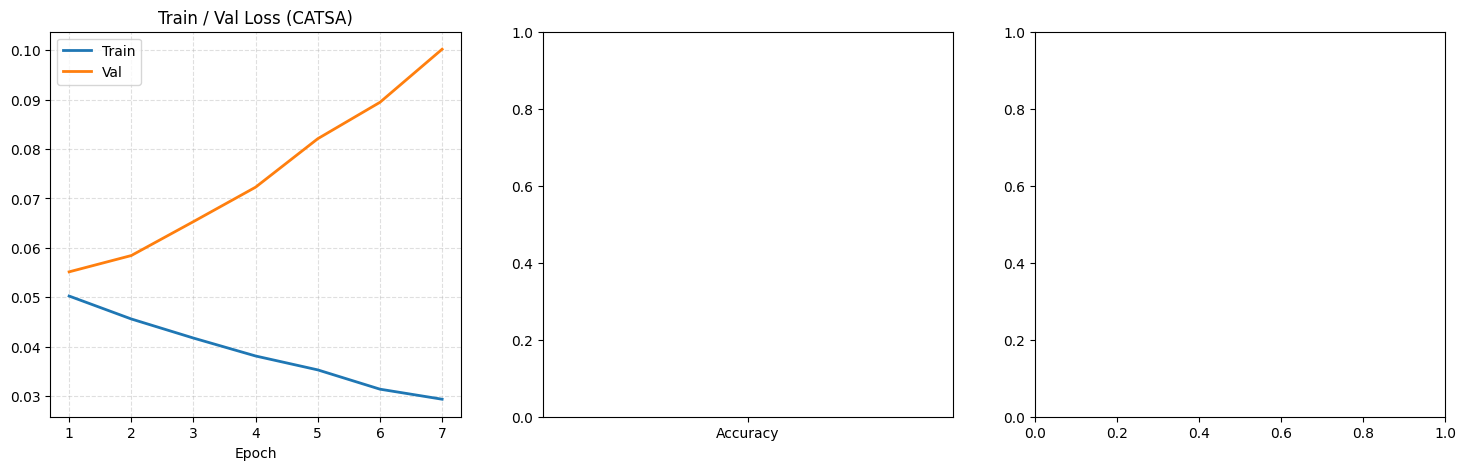

In [ ]:
# ── Visualization ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_list = [h["epoch"] for h in history]
axes[0].plot(epochs_list, [h["train_loss"] for h in history], label="Train", linewidth=2)
axes[0].plot(epochs_list, [h["val_loss"]   for h in history], label="Val",   linewidth=2)
axes[0].set_title("Train / Val Loss (CATSA)"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(linestyle="--", alpha=0.4)

if all_true:
    bars = axes[1].bar(["Accuracy","F1","Precision","Recall"],
                       [ov_acc, ov_f1, ov_prec, ov_rec],
                       color=["#4C78A8","#F58518","#54A24B","#A83A3A"])
    axes[1].set_ylim(0, 1.0); axes[1].set_title("Overall Metrics on EmpaticaE4")
    axes[1].grid(axis="y", linestyle="--", alpha=0.4)
    for b, v in zip(bars, [ov_acc, ov_f1, ov_prec, ov_rec]):
        axes[1].text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.4f}",
                     ha="center", va="bottom", fontsize=9)

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    im = axes[2].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    axes[2].set_title("Normalized Confusion Matrix")
    axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
    axes[2].set_xticklabels(["Non-stress","Stress"])
    axes[2].set_yticklabels(["Non-stress","Stress"])
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
    thr = cm_norm.max() / 2
    for i in range(2):
        for j in range(2):
            axes[2].text(j, i, f"{cm_norm[i,j]:.3f}\n({cm[i,j]})",
                         ha="center", va="center",
                         color="white" if cm_norm[i,j] > thr else "black", fontsize=11)
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

fig.suptitle("Chronos-2 (Chronos-T5-small) — CATSA→EmpaticaE4 (ACC)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results.png")